In [ ]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.plot import(
    plot_csi_sorted_sequence_exact,
)
from torch.utils.data import DataLoader
from src.utils import crop_back, pad_to_32,merge_day_night_on_time

In [ ]:
from src.model import GUM 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.5).to(device)
PATH = "Model_checkpoint/best_gum.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)
model.to(device)
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
minmax =  np.load("Data/static/minmax_strat.npz")
channel_min, channel_max = minmax["channel_min"], minmax["channel_max"]

In [4]:
#load night data with elevation and landmask
bands_npz_name = "Data/bands/modeldata/bands_night_paired_30mins_fuzzy_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"

In [ ]:
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/combined_hourly_with_elev_landmask_fuzzy_night.npz",
)

In [6]:
X_test, y_test = load_bands_and_cams(
    bands_npz_path="Data/output/combined_hourly_with_elev_landmask_fuzzy_night.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_night_paired_30mins_fuzzy_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (59236, 12, 50, 50)
y shape: (59236, 1, 50, 50)
X finite: True
y finite: True
X stats: min -54.519989013671875 max 804.1715698242188
y stats: min 0.0 max 1.0


In [7]:
night_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
night_loader  = DataLoader(night_dataset,  batch_size=64, shuffle=False)

In [ ]:
# save synthetic night CSI
# y_pred = []
# model.eval()
# with torch.no_grad():
#     for x_batch, y_batch in night_loader:
#         x_batch = x_batch.to(device)
#         xb_pad, h, w = pad_to_32(x_batch)

#         pred_y = model(xb_pad)
#         if isinstance(pred_y, (tuple, list)):
#             pred_y = pred_y[0]
#             pred_y = crop_back(pred_y, h, w).contiguous()
#             y_pred.append(pred_y.cpu().numpy())
# y_pred = np.concatenate(y_pred, axis=0)

# out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz"
# night_t    = np.load(bands_npz_name)["time_min"]
# np.savez_compressed(
#     out_path,
#     csi=y_pred,
#     time_hourly=night_t,
# )
# print("Saved synthetic night CSI to", out_path)
# print("y_pred night shape:", y_pred.shape)

In [8]:
data= np.load("Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz")
y_pred = data["csi"]
night_t = data["time_hourly"]

In [10]:
import numpy as np
out_path = "Data/syntheticCSI/csi_synthetic_hourly_night_fuzzy_pub.npz"
# --- DAY truth CSI from CAMS (ghi_grid2500_2ch_day.npz) ---
cams_day_npz = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_fuzzy_no_twillight.npz", allow_pickle=True)
cams_day     = cams_day_npz["data"].astype(np.float32)   # (T_day, 2, 50, 50)
time_day     = cams_day_npz["time_min"]                      # (T_day,)
# load bands for time info only
night_t    = np.load(out_path)["time_hourly"]
eps = 1e-6
ghi_day    = cams_day[:, 0, :, :]  # (T_day, 50, 50)
ghi_cs_day = cams_day[:, 1, :, :]  # (T_day, 50, 50)

ghi_cs_safe = np.where(ghi_cs_day < eps, eps, ghi_cs_day)
csi_day = ghi_day / ghi_cs_safe                   # (T_day, 50, 50)
y_true_day = csi_day[:, None, :, :]               # (T_day, 1, 50, 50)
print("y_true_day:", y_true_day.shape)
print("y_pred_night:", night_t.shape)

y_true_day: (46277, 1, 50, 50)
y_pred_night: (59236,)


In [11]:
csi_sorted, time_sorted, is_day_sorted = merge_day_night_on_time(
    y_true_day, time_day,
    y_pred, night_t
)
print("sorted time range:", time_sorted[0], "→", time_sorted[-1])
print("frames:", len(time_sorted), "day:", is_day_sorted.sum(), "night:", (~is_day_sorted).sum())

sorted time range: 2021-01-01 10:30:00 → 2023-12-31 23:40:00
frames: 105513 day: 46277 night: 59236


In [12]:
import numpy as np
import pandas as pd

def merge_day_night_on_time_hourly(
    y_true_day, time_day,
    y_pred_night, time_night,
    *,
    unit="m",      # same as before
    origin="unix",
):
    time_day   = np.asarray(time_day).astype(np.int64)
    time_night = np.asarray(time_night).astype(np.int64)

    # --- filter to hourly timestamps only (exact hour boundary) ---
    dt_day   = pd.to_datetime(time_day,   unit=unit, origin=origin)
    dt_night = pd.to_datetime(time_night, unit=unit, origin=origin)

    day_mask   = (dt_day.minute == 0) & (dt_day.second == 0) & (dt_day.microsecond == 0)
    night_mask = (dt_night.minute == 0) & (dt_night.second == 0) & (dt_night.microsecond == 0)

    time_day_h   = time_day[day_mask]
    y_true_day_h = y_true_day[day_mask]

    time_night_h   = time_night[night_mask]
    y_pred_night_h = y_pred_night[night_mask]

    # maps keep LAST occurrence (matches your original dict behavior)
    day_map   = {t: i for i, t in enumerate(time_day_h)}
    night_map = {t: i for i, t in enumerate(time_night_h)}

    all_times_raw = np.array(sorted(set(day_map) | set(night_map)), dtype=np.int64)

    C, H, W = y_true_day.shape[1:]
    T_total = len(all_times_raw)

    csi_sorted    = np.full((T_total, C, H, W), np.nan, dtype=np.float32)
    is_day_sorted = np.zeros(T_total, dtype=bool)

    for k, t in enumerate(all_times_raw):
        if t in day_map:  # day wins on duplicates
            csi_sorted[k] = y_true_day_h[day_map[t]]
            is_day_sorted[k] = True
        else:
            csi_sorted[k] = y_pred_night_h[night_map[t]]
            is_day_sorted[k] = False

    all_times = pd.to_datetime(all_times_raw, unit=unit, origin=origin)
    return csi_sorted, all_times, is_day_sorted


In [13]:
csi_h, hours, is_day_h = merge_day_night_on_time_hourly(
    y_true_day, time_day, y_pred, night_t
)

In [ ]:
hours.shape

In [ ]:
# np.savez_compressed(
#     "Data/syntheticCSI/csi_synthetic_hourly_merged_day_night_fuzzy_pub.npz",
#     csi=csi_h,
#     time_hourly=hours,
# )

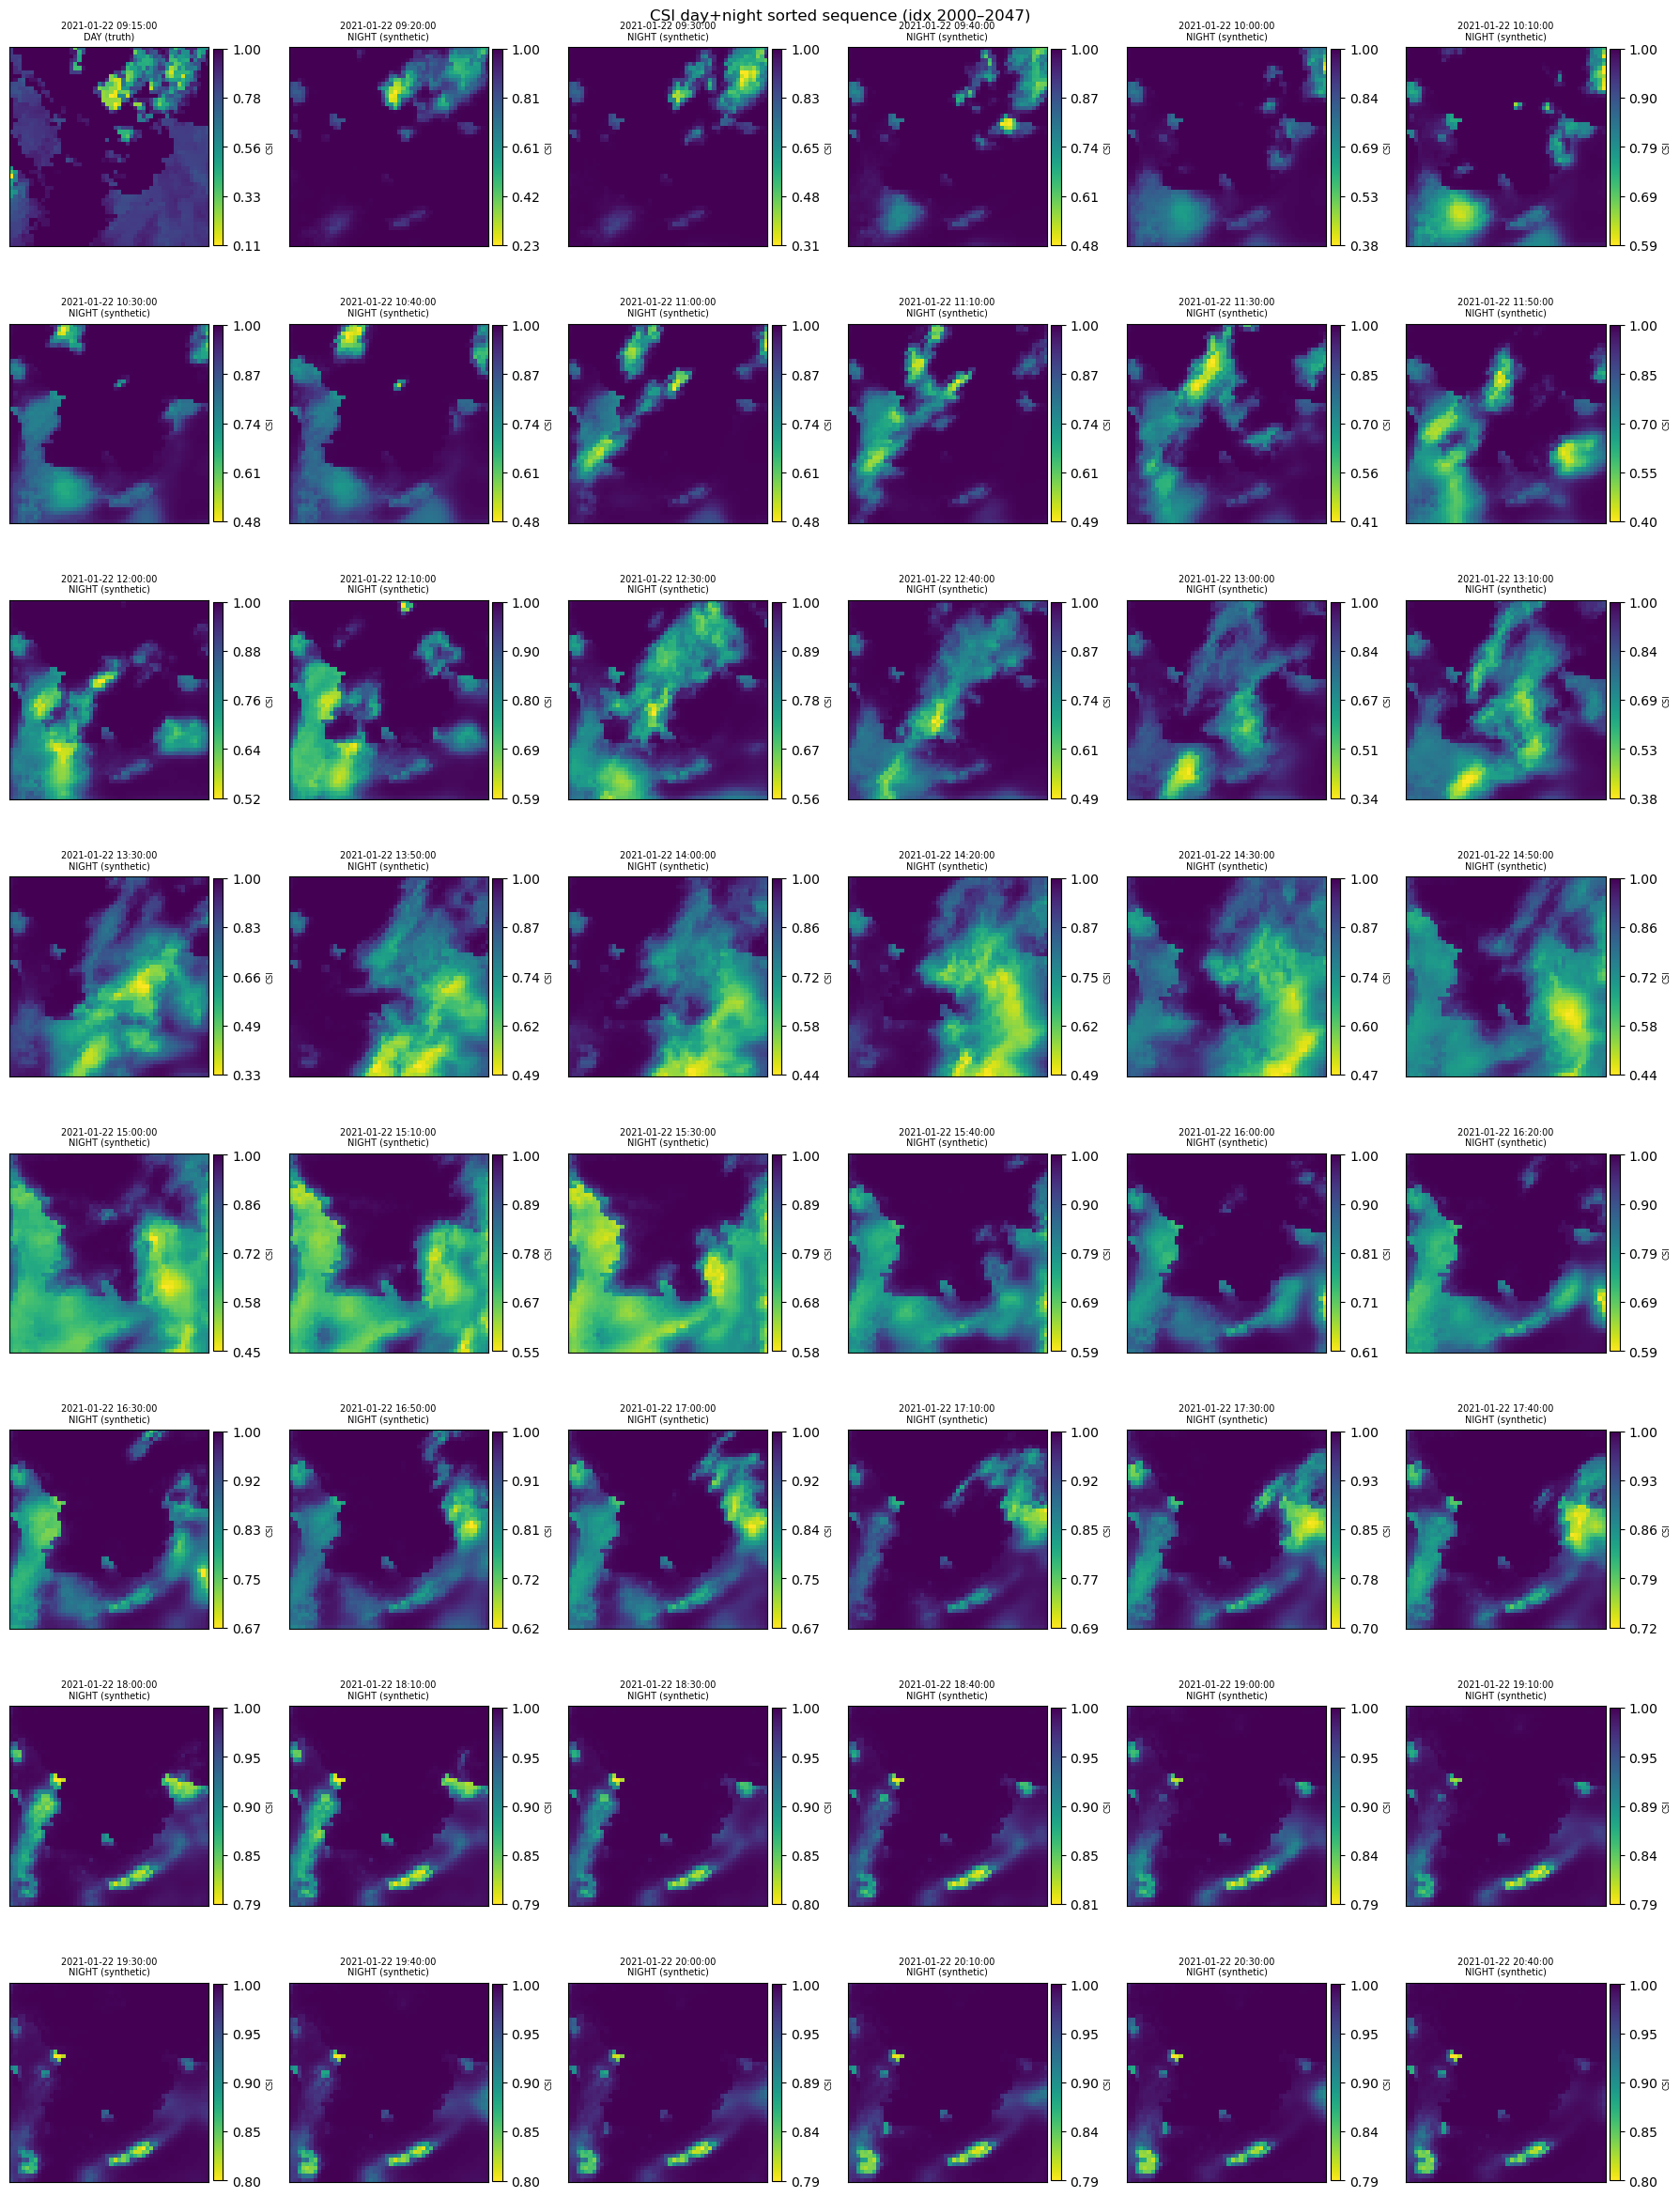

In [14]:
# first 24 hours in the whole period
plot_csi_sorted_sequence_exact(
    csi_sorted, time_sorted, is_day_sorted,
    start_idx=2000,
    num_steps=24*2,
    cols=6,
)

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

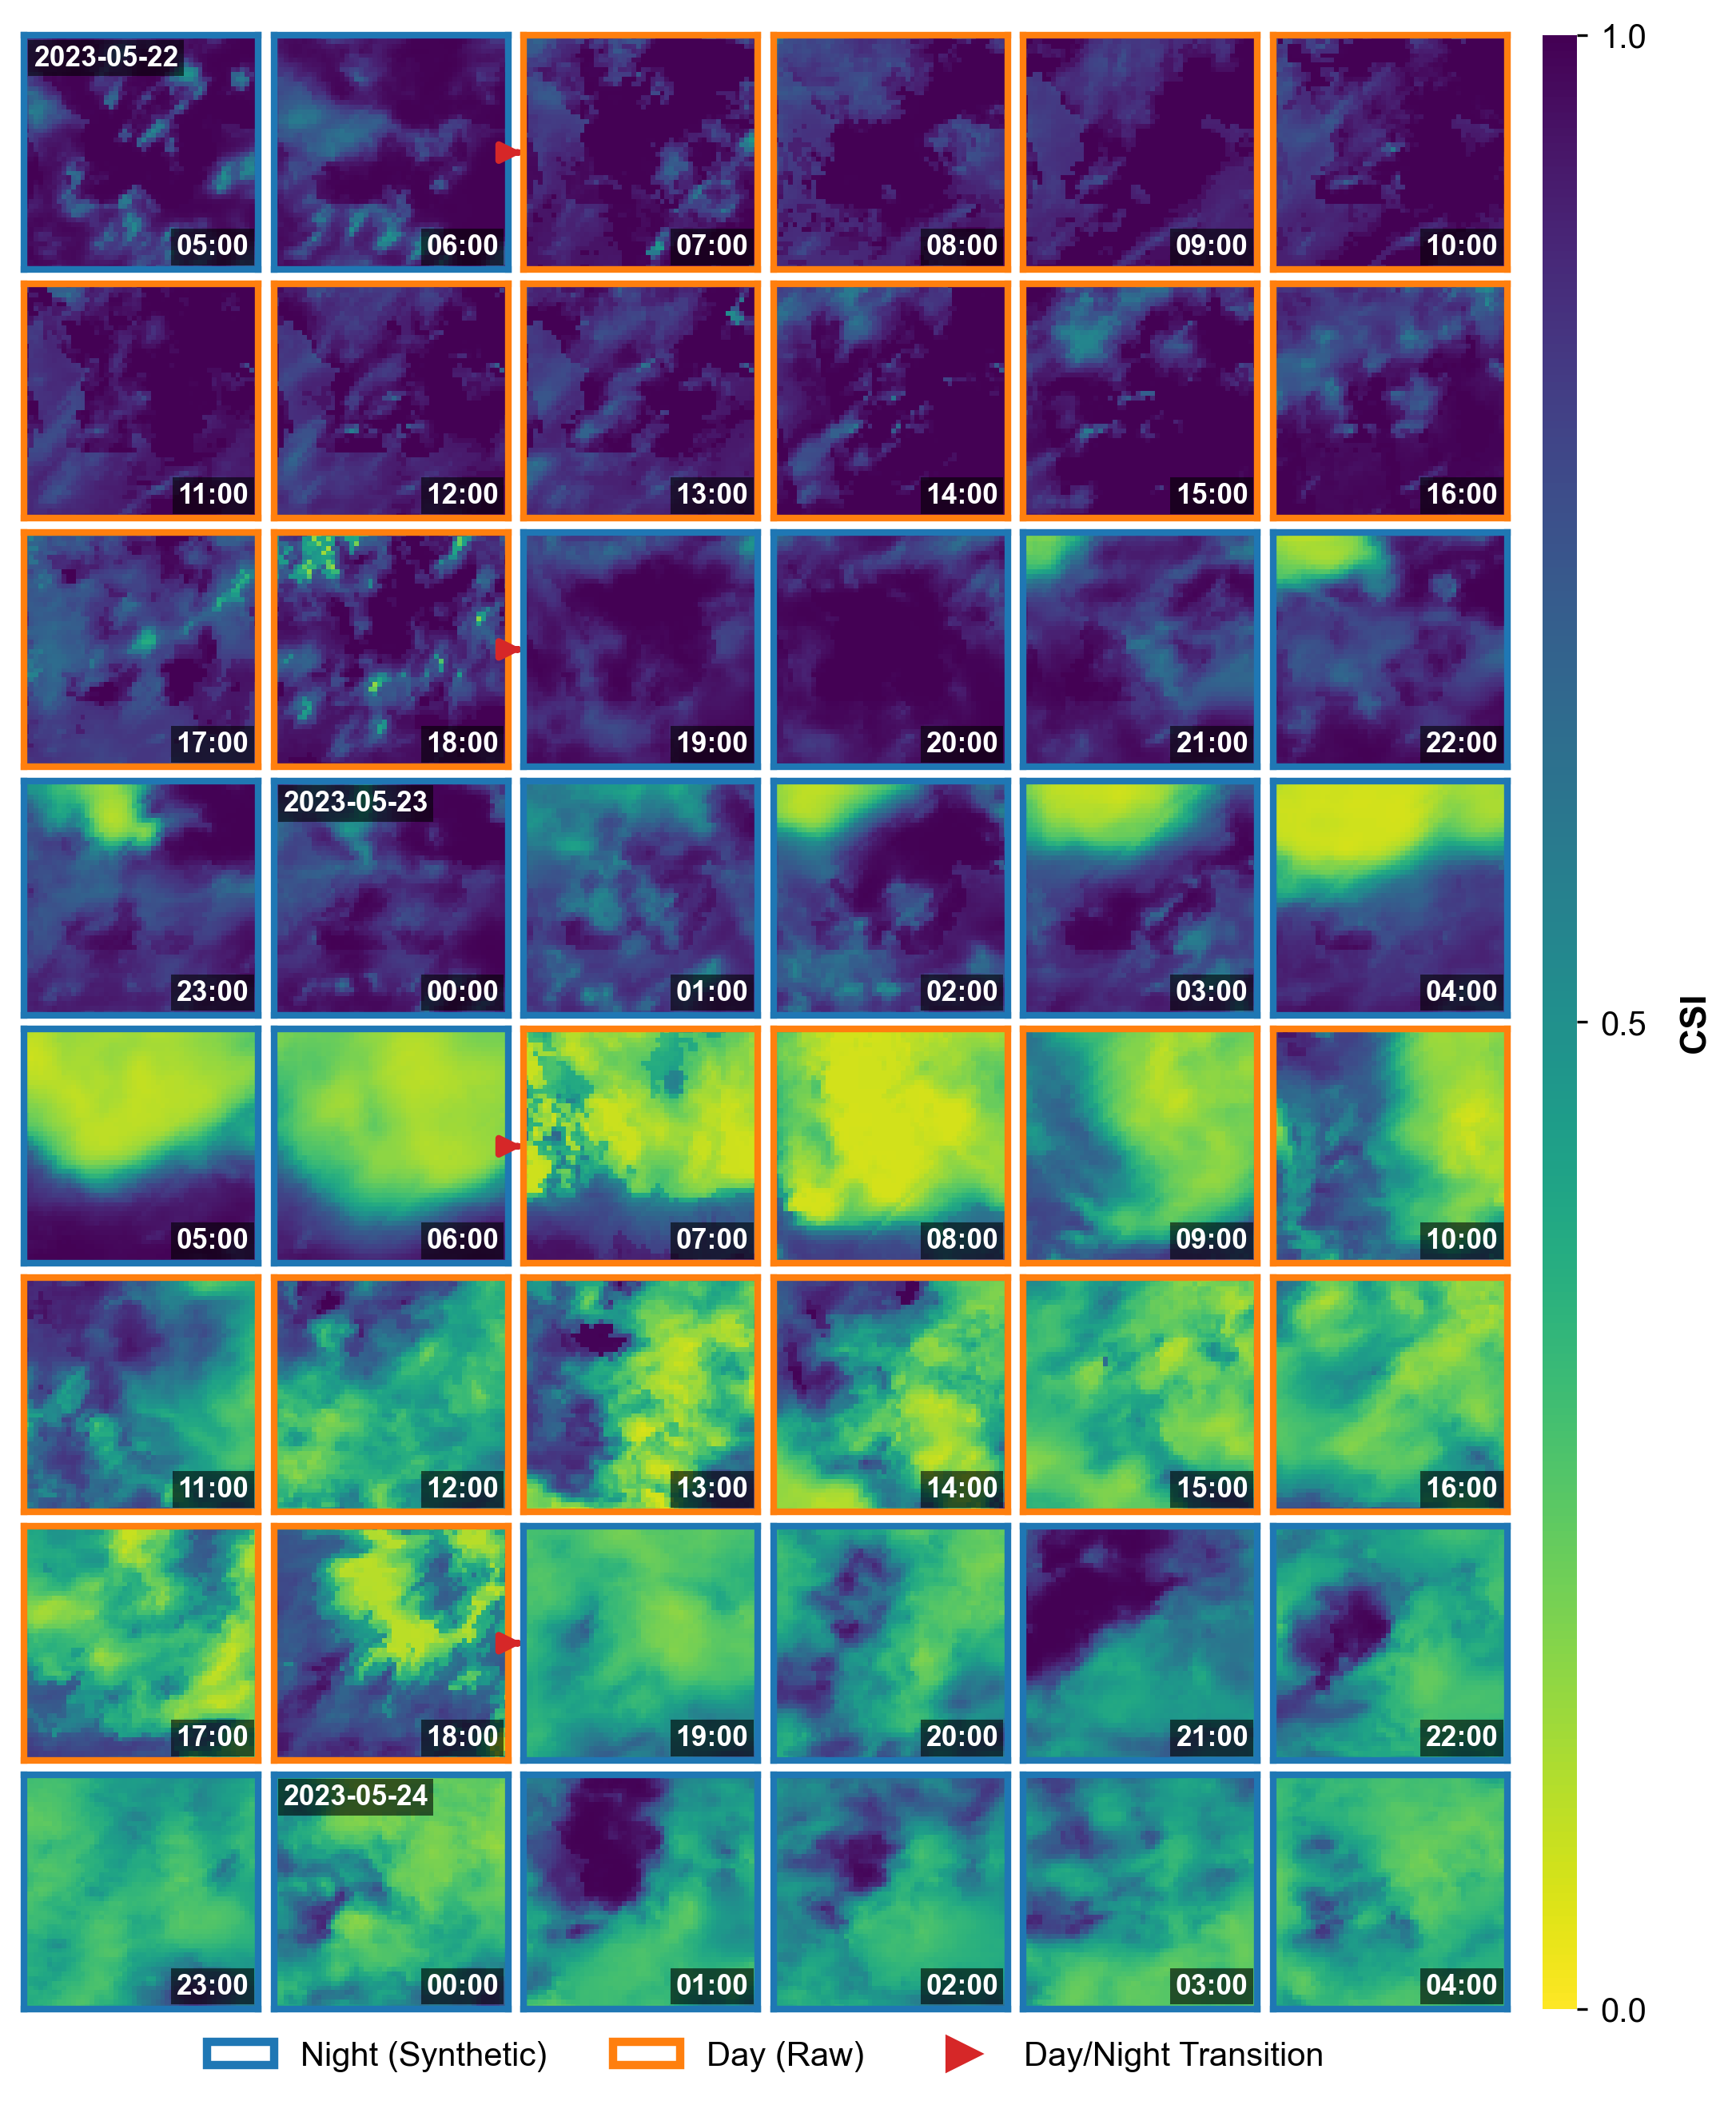

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def plot_csi_journal_final_v5_pro(
    csi_sorted,
    time_sorted,
    is_day_sorted,
    start_idx=0,
    num_steps=48,
    cols=6,
):
    # --------------------------------------------------------
    # 0. JOURNAL SETTINGS & CONSTANTS
    # --------------------------------------------------------
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })
    
    COLOR_NIGHT = "#1f77b4" 
    COLOR_DAY = "#ff7f0e"   
    TRANS_ARROW = "#d62728" 
    BORDER_LW = 2.0         
    
    end_idx = min(start_idx + num_steps, csi_sorted.shape[0])
    frames_count = end_idx - start_idx
    rows = int(np.ceil(frames_count / cols))
    
    # --------------------------------------------------------
    # 1. SETUP FIGURE ARCHITECTURE 
    # --------------------------------------------------------
    # We reduced the figure height multiplier from 1.29 to 1.21. 
    # This physically shrinks the empty space at the bottom of the page.
    fig_height = rows * 1.21 
    fig = plt.figure(figsize=(7.2, fig_height), dpi=300)
    
    # INCREASED SPACING: wspace and hspace bumped from 0.04 to 0.06
    # DECREASED GAP: 'bottom' raised from 0.15 to 0.10 to pull the legend up
    gs = fig.add_gridspec(rows, cols, left=0.02, right=0.88, top=0.95, bottom=0.10, 
                          wspace=0.06, hspace=0.06)
    
    last_date_hkt = None
    im = None 

    # --------------------------------------------------------
    # 2. PLOT FRAMES
    # --------------------------------------------------------
    for i in range(frames_count):
        idx = start_idx + i
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])
        
        utc_time = pd.Timestamp(time_sorted[idx])
        hkt_time = utc_time + pd.Timedelta(hours=8)
        current_date_hkt = hkt_time.strftime('%Y-%m-%d')
        
        frame = csi_sorted[idx, 0]
        vmin, vmax = 0, 1
        im = ax.imshow(frame, cmap="viridis_r", vmin=vmin, vmax=vmax)
        
        # Borders (Day/Night)
        is_day = is_day_sorted[idx]
        current_color = COLOR_DAY if is_day else COLOR_NIGHT
        for spine in ax.spines.values():
            spine.set_edgecolor(current_color)
            spine.set_linewidth(BORDER_LW)
            
        # --------------------------------------------------------
        # EXACT ARROW PLACEMENT
        # --------------------------------------------------------
        if i < frames_count - 1 and is_day_sorted[idx] != is_day_sorted[idx+1] and (i + 1) % cols != 0:
            # The gap is now 0.06. 
            # Arrow starts at 1.01 (just off the edge) and ends exactly at 1.06
            ax.annotate('', xy=(1.06, 0.5), xycoords='axes fraction', 
                        xytext=(1.01, 0.5), 
                        arrowprops=dict(arrowstyle="-|>", color=TRANS_ARROW, 
                                        lw=2.0, mutation_scale=12),
                        zorder=10, annotation_clip=False)

        # --------------------------------------------------------
        # EMBEDDED TEXT LABELS
        # --------------------------------------------------------
        if current_date_hkt != last_date_hkt:
            ax.text(0.04, 0.96, current_date_hkt, transform=ax.transAxes, 
                    fontsize=8.5, fontweight='black', color='white', 
                    ha='left', va='top', 
                    bbox=dict(facecolor='black', alpha=0.6, lw=0, pad=1.5))
            last_date_hkt = current_date_hkt

        ax.text(0.96, 0.04, hkt_time.strftime('%H:%M'), transform=ax.transAxes, 
                color='white', fontsize=8.5, fontweight='bold', 
                ha='right', va='bottom',
                bbox=dict(facecolor='black', alpha=0.6, lw=0, pad=1.5))

        ax.set_xticks([]); ax.set_yticks([])

    # --------------------------------------------------------
    # 3. SINGLE SHARED COLORBAR
    # --------------------------------------------------------
    # Stretched slightly to match the new grid boundaries (bottom=0.10, height=0.85)
    cax = fig.add_axes([0.90, 0.10, 0.02, 0.85]) 
    cb = fig.colorbar(im, cax=cax)
    cb.outline.set_visible(False)
    cb.set_ticks([0, 0.5, 1])
    cb.set_ticklabels(['0.0', '0.5', '1.0'])
    cb.ax.tick_params(labelsize=10, length=3, pad=4)
    cb.set_label("CSI", fontweight='bold', fontsize=11, labelpad=10)

    # --------------------------------------------------------
    # 4. GLOBAL LEGEND
    # --------------------------------------------------------
    legend_elements = [
        patches.Patch(edgecolor=COLOR_NIGHT, facecolor='none', lw=2.5, label='Night (Synthetic)'),
        patches.Patch(edgecolor=COLOR_DAY, facecolor='none', lw=2.5, label='Day (Raw)'),
        Line2D([0], [0], color=TRANS_ARROW, lw=2.5, marker='>', markersize=10, 
               label='Day/Night Transition', linestyle='None')
    ]
    
    # Positioned precisely in the newly shortened bottom margin
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
               frameon=False, fontsize=10, bbox_to_anchor=(0.45, 0.06))

    plt.savefig("csi_syn_raw_clear_gold.pdf", dpi=800, bbox_inches='tight')
    plt.show()
# Run this:
plot_csi_journal_final_v5_pro(csi_h, hours, is_day_h, start_idx=20496+(24*11), num_steps=48)

In [ ]:
# mix: 20500+(24*11)
